In [ ]:
import sinter
import stim
from typing import List
from mwpf import SinterMWPFDecoder

noise = [0.01, 0.05, 0.08, 0.1, 0.2, 0.3, 0.4, 0.5]
code_distance = [3, 5, 7, 9]

task_configs = [
    dict(
        circuit=stim.Circuit.generated(
            "repetition_code:memory",
            rounds=d * 3,
            distance=d,
            before_round_data_depolarization=p,
        ),
        json_metadata={"d": d, "p": p},
    )
    for d in code_distance
    for p in noise
]

In [ ]:
for task in task_configs:
    print(f"**** BEGIN repetition_code:memory {task['json_metadata']}")
    print(task["circuit"])
    print(f"**** END repetition_code:memory {task['json_metadata']}")

**** BEGIN repetition_code:memory {'d': 3, 'p': 0.01}
R 0 1 2 3 4
TICK
DEPOLARIZE1(0.01) 0 2 4
CX 0 1 2 3
TICK
CX 2 1 4 3
TICK
MR 1 3
DETECTOR(1, 0) rec[-2]
DETECTOR(3, 0) rec[-1]
REPEAT 8 {
    TICK
    DEPOLARIZE1(0.01) 0 2 4
    CX 0 1 2 3
    TICK
    CX 2 1 4 3
    TICK
    MR 1 3
    SHIFT_COORDS(0, 1)
    DETECTOR(1, 0) rec[-2] rec[-4]
    DETECTOR(3, 0) rec[-1] rec[-3]
}
M 0 2 4
DETECTOR(1, 1) rec[-2] rec[-3] rec[-5]
DETECTOR(3, 1) rec[-1] rec[-2] rec[-4]
OBSERVABLE_INCLUDE(0) rec[-1]
**** END repetition_code:memory {'d': 3, 'p': 0.01}
**** BEGIN repetition_code:memory {'d': 3, 'p': 0.05}
R 0 1 2 3 4
TICK
DEPOLARIZE1(0.05) 0 2 4
CX 0 1 2 3
TICK
CX 2 1 4 3
TICK
MR 1 3
DETECTOR(1, 0) rec[-2]
DETECTOR(3, 0) rec[-1]
REPEAT 8 {
    TICK
    DEPOLARIZE1(0.05) 0 2 4
    CX 0 1 2 3
    TICK
    CX 2 1 4 3
    TICK
    MR 1 3
    SHIFT_COORDS(0, 1)
    DETECTOR(1, 0) rec[-2] rec[-4]
    DETECTOR(3, 0) rec[-1] rec[-3]
}
M 0 2 4
DETECTOR(1, 1) rec[-2] rec[-3] rec[-5]
DETECTOR(3, 1) rec[-1

In [ ]:
tasks = [sinter.Task(**task) for task in task_configs]


mwpf_collected_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=["mwpf"],
    custom_decoders={"mwpf": SinterMWPFDecoder(cluster_node_limit=50)},
    max_shots=100_000,
    max_errors=500,
)

pymatching_collected_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=["pymatching"],
    max_shots=100_000,
    max_errors=500,
)

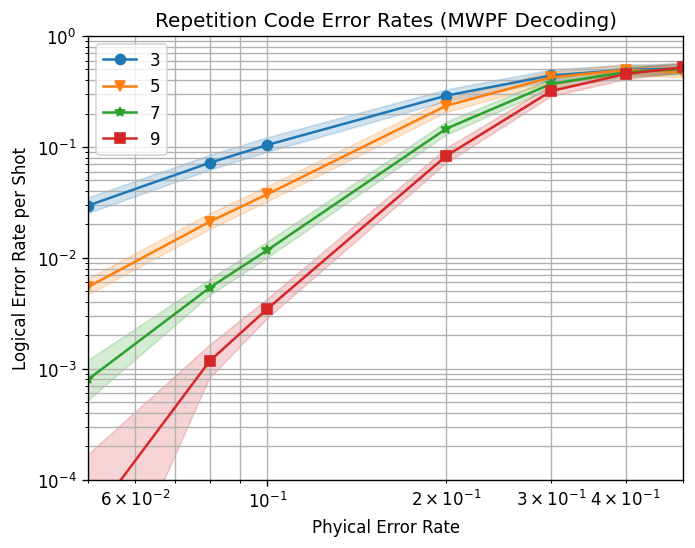

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=mwpf_collected_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: stats.json_metadata["d"],
)
ax.set_ylim(1e-4, 1e-0)
ax.set_xlim(5e-2, 5e-1)
ax.loglog()
ax.set_title("Repetition Code Error Rates (MWPF Decoding)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(120)

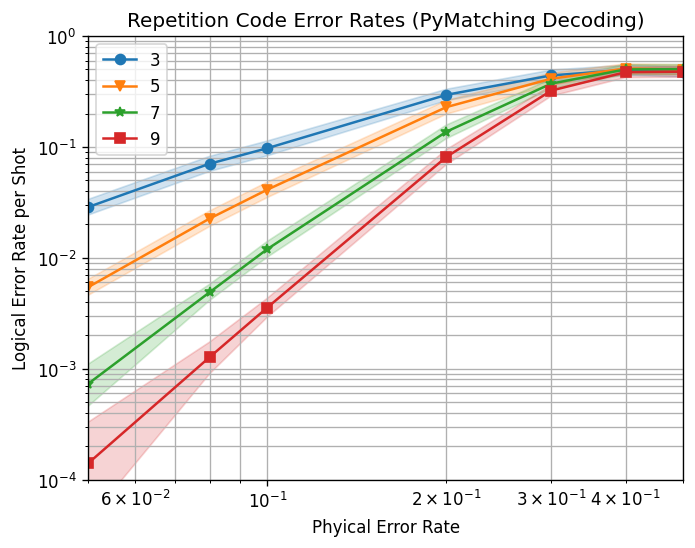

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=pymatching_collected_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: stats.json_metadata["d"],
)
ax.set_ylim(1e-4, 1e-0)
ax.set_xlim(5e-2, 5e-1)
ax.loglog()
ax.set_title("Repetition Code Error Rates (PyMatching Decoding)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(120)

In [ ]:
# From the docs:
# MWPF decoder now supports heralded error decoding in stim circuit!
#   Since the sinter.Decoder interface only gives a DEM (Detector Error Model), which doesn't include heralded error
#   information, you need to manually provide the circuit when constructing the decoder, like below
# custom_decoders = { "mwpf": SinterMWPFDecoder(cluster_node_limit=50).with_circuit(circuit) }
from dataclasses import replace
import mwpf.ref_circuit
from typing import Tuple
from uuid import uuid4

noise = [0.01, 0.05, 0.08, 0.1, 0.2, 0.3, 0.4, 0.5]
code_distance = [3, 5, 7, 9]

erasure_task_configs = [
    dict(
        circuit=stim.Circuit.generated(
            "repetition_code:memory",
            rounds=d * 3,
            distance=d,
            before_round_data_depolarization=p,
        ),
        json_metadata={"d": d, "p": p, "run_id": str(uuid4())},
    )
    for d in code_distance
    for p in noise
]

In [ ]:
# TODO - if we use individual errors e.g. X_ERROR Y_ERROR Z_ERROR instead of randomized DEPOLARIZE1/2 noise
CONVERT_TO_ERASURE_NOISE = ("DEPOLARIZE1", "DEPOLARIZE2")


def erasure_conversion(
    task_config: dict, conversion_factor: int = 1, add_detectors: bool = True
) -> dict:
    """Converts random pauli noise instructions (e.g. DEPOLARIZE1, DEPOLARIZE2) to HERALDED_ERASE instructions

    See notes in https://github.com/yuewuo/mwpf/blob/main/src/python/mwpf/ref_circuit.py
    for explanation of why reference circuits are needed to keep track of measurement indices w/ heralded errors
    """
    circuit = task_config["circuit"]
    json_metadata = task_config["json_metadata"]
    ref_circuit = mwpf.ref_circuit.RefCircuit.of(circuit)

    instructions: list[mwpf.ref_circuit.RefInstruction] = []
    for instruction in ref_circuit:
        if instruction.name in CONVERT_TO_ERASURE_NOISE:
            p = instruction.gate_args[0]
            instructions.append(replace(instruction, gate_args=[p * conversion_factor]))
            new_instruction = mwpf.ref_circuit.RefInstruction.new_heralded_erase(
                instruction.targets, min(1, 4 / 3 * p * conversion_factor)
            )
            instructions.append(new_instruction)
            if add_detectors is True:
                for rec in new_instruction.recs:
                    instructions.append(
                        mwpf.ref_circuit.RefInstruction.new_detector((rec,))
                    )
        else:
            instructions.append(instruction)
    converted_metadata = json_metadata.copy()
    converted_metadata["p_erase"] = converted_metadata["p"]
    converted_metadata["p"] = 0

    converted_circuit = mwpf.ref_circuit.RefCircuit.of(instructions).circuit()
    new_task_config = dict(
        circuit=converted_circuit, json_metadata=converted_metadata, decoder="mwpf"
    )
    return new_task_config


converted_erasure_task_configs = list(map(erasure_conversion, erasure_task_configs))

In [ ]:
tasks = [sinter.Task(**task) for task in converted_erasure_task_configs]


def sinter_with_custom_decoder(task_config: dict):
    task = sinter.Task(**task_config)
    result = sinter.collect(
        num_workers=4,
        tasks=[task],
        decoders=["mwpf"],
        custom_decoders={
            "mwpf": SinterMWPFDecoder(cluster_node_limit=50).with_circuit(
                task_config["circuit"]
            )
        },
        max_shots=1000,
        max_errors=100,
        print_progress=True,
    )
    return result


erasure_collected_stats = list(
    map(sinter_with_custom_decoder, converted_erasure_task_configs)
)
erasure_collected_stats

Starting 4 workers...
1 tasks left:
  workers decoder eta shots_left errors_left json_metadata                                                   
        4    mwpf <1m        750          99 d=3,p=0,run_id=188424f8-3eeb-4caf-b65c-7fb1094c5631,p_erase=0.01
0 tasks left:

Starting 4 workers...
1 tasks left:
  workers decoder eta shots_left errors_left json_metadata                                                   
        4    mwpf <1m        750          87 d=3,p=0,run_id=2b72cd14-bedf-4acf-8190-bc2869b2ca89,p_erase=0.05
0 tasks left:

Starting 4 workers...
1 tasks left:
  workers decoder eta shots_left errors_left json_metadata                                                   
        4    mwpf <1m        750          60 d=3,p=0,run_id=13cee51d-8d23-4083-a1eb-e87323730116,p_erase=0.08
1 tasks left:
  workers decoder        eta shots_left errors_left json_metadata                                                   
        4    mwpf [draining]        249         -36 d=3,p=0,run_id=13ce

[[sinter.TaskStats(strong_id='6eb12df51d6bdf3feab45fcbb93670db7b58c1c3734fea281b59d772e4a9e827', decoder='mwpf', json_metadata={'d': 3, 'p': 0, 'run_id': '188424f8-3eeb-4caf-b65c-7fb1094c5631', 'p_erase': 0.01}, shots=1000, errors=4, seconds=0.009791459771804512)],
 [sinter.TaskStats(strong_id='5a1474c6787ea7d700c1d3bb7195ace47db1a9c5dff4595e336561f02ebdd7f4', decoder='mwpf', json_metadata={'d': 3, 'p': 0, 'run_id': '2b72cd14-bedf-4acf-8190-bc2869b2ca89', 'p_erase': 0.05}, shots=1000, errors=74, seconds=0.014779334072954953)],
 [sinter.TaskStats(strong_id='6b07a6170a9822cfd5aa49bf00d9ab00785b8494a2b603bb0954a20dcbff9a0e', decoder='mwpf', json_metadata={'d': 3, 'p': 0, 'run_id': '13cee51d-8d23-4083-a1eb-e87323730116', 'p_erase': 0.08}, shots=751, errors=136, seconds=0.01341433310881257)],
 [sinter.TaskStats(strong_id='dee20c24e06f0390b3d4172858928deef1eacee6fc83a55fbe9898b0ea6839d3', decoder='mwpf', json_metadata={'d': 3, 'p': 0, 'run_id': '19e4337e-4246-498c-8738-34441b119107', 'p_eras

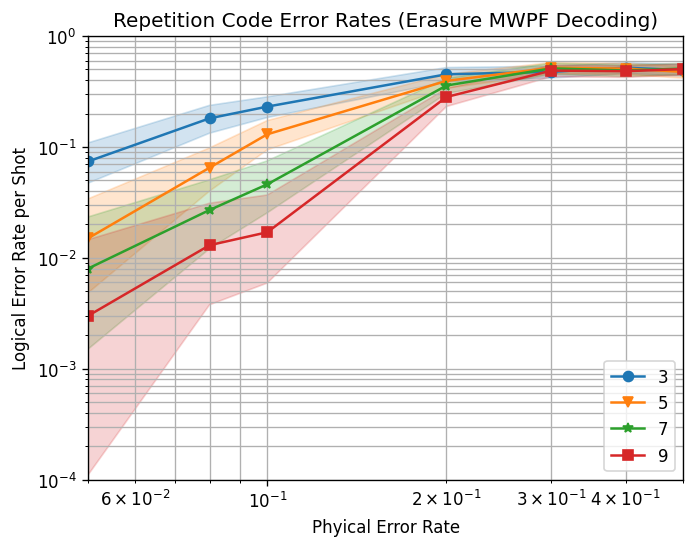

In [ ]:
import itertools

erasure_collected_stats = list(itertools.chain.from_iterable(erasure_collected_stats))
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=erasure_collected_stats,
    x_func=lambda stats: stats.json_metadata["p_erase"],
    group_func=lambda stats: stats.json_metadata["d"],
)
ax.set_ylim(1e-4, 1e-0)
ax.set_xlim(5e-2, 5e-1)
ax.loglog()
ax.set_title("Repetition Code Error Rates (Erasure MWPF Decoding)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(120)

In [13]:
erasure_collected_stats[0]

[sinter.TaskStats(strong_id='6eb12df51d6bdf3feab45fcbb93670db7b58c1c3734fea281b59d772e4a9e827', decoder='mwpf', json_metadata={'d': 3, 'p': 0, 'run_id': '188424f8-3eeb-4caf-b65c-7fb1094c5631', 'p_erase': 0.01}, shots=1000, errors=4, seconds=0.009791459771804512)]